In [5]:
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


# Principal Component Analysis (PCA)

## 🎯 What problem does PCA solve?

Energy datasets often have **many correlated features** (24 hourly loads, weather, tariffs, PV, etc.). PCA compresses them into a **few orthogonal patterns** (principal components, PCs) that explain most of the variability with minimal information loss.

> Think of it as discovering the main “stories” your data keeps telling—without the noise.

---

## 🧩 What is a principal component?

A **principal component** is a **direction** in feature space that captures as much variance as possible, subject to being orthogonal to earlier components.

* **Loadings** = the recipe: how each original feature (e.g., `h0..h23`, `t_mean`, `price`) contributes to a component.
* **Scores** = the amount of that recipe each sample/day has.
* **Explained variance** = how much of your dataset’s variability that component covers.

---

## 🔌 Energy intuition (how components look)

Imagine each row is one **day** with 24 hourly kWh + weather:

* **PC1 (base pattern)**: all daytime hours positive and similar → captures **baseline + typical daily shape**.
* **PC2 (shape trade-off)**: morning hours positive, evening negative (or vice versa) → **morning vs evening** dominance.
* **PC3 (regime effect)**: weekend hours load differently from weekdays, or a **midday dip** aligned with **PV generation**.
* **Weather/price PCs**: large positive loadings on hot-hour loads and on `t_mean` → **cooling demand**; negative loadings aligned with `price` during peak TOU → **price responsiveness**.

You don’t “name” components by formula—you **interpret** them by reading the loadings like a fingerprint.

---

## 🧪 Reading PCA outputs like a pro

1. **Scree plot**: pick the number of PCs where the curve bends (“elbow”) or where cumulative variance ≥ **90–95%**.
2. **Loadings table**:

   * Large **same-sign** loadings across h9–h17 → a **daytime mode**.
   * **Opposite signs** across morning vs evening → a **timing trade-off**.
   * Big loading on `t_mean` alongside late-afternoon hours → **heat-driven peak**.
3. **Scores scatter (PC1 vs PC2)**:

   * Clusters = **regimes** (winter vs summer, weekday vs weekend).
   * Outliers = **anomalies** (stuck HVAC, holidays, data glitches).

---

## 🛠️ How you actually use PCA in energy workflows

* **Feature compression for forecasting** 🔮: Replace 24 hourly columns with 3–6 **PC scores** → simpler, less collinear models with similar accuracy.
* **Archetype discovery** 🏢: Run PCA on normalized daily profiles across buildings; cluster the **scores** to find archetypes (office 9–18, retail evening, 24/7).
* **PV + load disentangling** ☀️⚡: A component with negative midday loadings and positive PV/irradiance suggests **self-consumption** shaping the net load.
* **Anomaly detection** 🚨: Reconstruct each day from first *k* PCs; large residual = unusual day → investigate.
* **Tariff impact** 💶: If a component aligns with peak-price hours and scores correlate with price, you’ve got **price-responsive behavior**.

---

## 🧭 Minimal interpretation recipe (step-by-step)

1. **Standardize** all inputs (kWh, °C, € on equal footing).
2. Choose PCs by **cumulative variance** (target 90–95%).
3. Inspect **loadings**: list top 8–10 contributors per PC and describe the pattern in words.
4. Plot **scores** by season/weekday to see regimes.
5. Validate with domain knowledge (does PC2’s evening emphasis match operations or PV deficit?).
6. Use **scores** in your model or monitoring dashboards; track **residuals** for faults.

---

## ⚠️ Common pitfalls (and quick fixes)

* **Unscaled features** → PCA is unit-sensitive → **always standardize**.
* **Mixed regimes** in one PCA (winter+summer) blur patterns → split by regime or include dummies.
* **Over-interpretation** → PCs are **correlational**, not causal → corroborate.
* **Too few PCs** → underfit reconstructions (miss important patterns) → check residuals.
* **Too many PCs** → you lose the benefit of simplification → stick to variance target or elbow.



# 🧪 Generate synthetic energy data (hourly → daily features)

This makes 365 days of hourly load with temperature, wind, price, and PV influence. It then reshapes to **24 hourly columns per day** (`h0..h23`) plus extras (`t_mean`, `wind`, `price`).


In [3]:
rng = np.random.default_rng(42)

# ----- 1) Hourly time index for one year
start = "2024-01-01"
end   = "2024-12-31 23:00"
idx_h = pd.date_range(start, end, freq="h")
n = len(idx_h)

# ----- 2) Weather + calendar features
doy = idx_h.day_of_year.to_numpy()
hour = idx_h.hour.to_numpy()
dow = idx_h.dayofweek.to_numpy()  # 0=Mon

# Temperature: simple annual sinusoid + noise (°C)
t_out = 6 + 12*np.sin(2*np.pi*(doy-30)/365) + rng.normal(0, 2, n)

# Wind (m/s) with weak weekly pattern
wind = 3 + 1.2*np.sin(2*np.pi*(dow)/7) + rng.normal(0, 0.8, n)
wind = np.clip(wind, 0, None)

# Day/night & occupancy profiles
workday = (dow < 5).astype(float)
weekend = 1 - workday
morning_bump = np.exp(-0.5*((hour-9)/2.5)**2)
evening_peak = np.exp(-0.5*((hour-19)/2.8)**2)
night = ((hour<=6) | (hour>=23)).astype(float)

# PV profile (kW, proxy): midday bell + seasonal amplitude
pv_midday = np.exp(-0.5*((hour-12)/3.0)**2)
pv_season = 0.6 + 0.4*np.sin(2*np.pi*(doy-80)/365)  # more in summer
pv_kw = 3.5 * pv_midday * np.clip(pv_season, 0, None)
# small clouds noise
pv_kw *= np.clip(1 + rng.normal(0, 0.08, n), 0, None)

# Price (€/kWh) with TOU + random daily level
daily_level = 0.12 + 0.02*np.sin(2*np.pi*(doy)/14) + rng.normal(0, 0.01, n)
tou = 0.02*( (hour>=8)&(hour<=11) ) + 0.03*( (hour>=17)&(hour<=21) )
price = np.clip(daily_level + tou, 0.05, None)

# ----- 3) True load synthesis (kWh)
# Base + workday structure + weather sensitivity + PV self-consumption effect
base = 0.9 + 0.15*workday + 0.05*weekend
shape = 0.35*morning_bump + 0.55*evening_peak + 0.1*night
temp_effect = 0.03*np.maximum(20 - t_out, 0) + 0.02*np.maximum(t_out - 24, 0)  # heating + cooling
price_shift = -0.12*tou*price  # small reduction at high TOU (elasticity proxy)
pv_self_cons = -0.25*pv_kw     # PV lowers net demand (behind-the-meter)
noise = rng.normal(0, 0.08, n)

load_kwh = np.clip(base + shape + temp_effect + price_shift + pv_self_cons + noise, 0.05, None)

# ----- 4) Assemble hourly dataframe
df_h = pd.DataFrame({
    "ts": idx_h,
    "load": load_kwh,
    "t_out": t_out,
    "wind": wind,
    "price": price,
    "pv": pv_kw,
    "dow": dow,
})
df_h["date"] = df_h["ts"].dt.date
df_h["hour"] = df_h["ts"].dt.hour

# ----- 5) Daily features: h0..h23 + extras
# pivot to wide (24 hourly columns)
wide = df_h.pivot_table(index="date", columns="hour", values="load")
wide.columns = [f"h{h}" for h in wide.columns]

extras = df_h.groupby("date").agg(
    t_mean=("t_out","mean"),
    wind=("wind","mean"),
    price=("price","mean"),
)

df = wide.join(extras)
df.index = pd.to_datetime(df.index)

# Optional: add weekday/weekend dummies (if you want them outside PCA)
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

print(df.shape)
df.head()




(366, 28)


,h0,h1,h2,h3,h4,h5,h6,h7,h8,h9,...,h18,h19,h20,h21,h22,h23,t_mean,wind,price,is_weekend
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,1.825245,1.728533,1.765869,1.695261,1.911754,1.947786,1.875336,1.818838,1.834161,1.963633,...,2.108718,2.174184,2.178795,2.225311,1.813753,1.939323,0.217159,3.329401,0.140468,0
2024-01-02,1.630939,1.803917,1.709785,1.733778,1.741957,1.749099,1.953160,1.873335,1.933130,1.827391,...,2.111387,2.068489,2.255913,2.126081,1.747304,1.933809,0.793270,3.934520,0.146710,0
2024-01-03,1.625725,1.758491,1.656208,1.667843,1.937981,1.902183,2.025241,1.856181,1.775639,1.867678,...,2.309005,2.259248,2.037368,2.008480,2.074270,2.117119,0.436705,4.022539,0.150094,0
2024-01-04,1.740508,1.661285,1.730576,1.590813,1.684813,1.708238,1.877465,1.872076,1.935463,1.776445,...,2.060827,2.222365,2.064024,2.038698,2.129031,2.181239,0.489955,3.520584,0.149388,0
2024-01-05,1.691500,1.808358,1.687139,1.783932,1.722025,1.786967,1.942621,1.977999,1.824559,1.735895,...,2.174078,2.265192,2.131604,2.170558,1.879204,1.889897,0.573100,2.664423,0.145597,0


**What you get**

* `df` with shape `[365, 24 + 3 (+1 optional)]`
* 24 hourly load columns: `h0..h23`
* Extras: `t_mean`, `wind`, `price` (and `is_weekend` if you keep it)

# 🧪 Minimal workflow (scikit-learn)

In [6]:


# Example: hourly features per day for one building (columns h0..h23) + weather
# df shape: [n_days, 24 + extras]
# Ensure no NaNs; impute or drop beforehand.
features = [f"h{h}" for h in range(24)] + ["t_mean", "wind", "price"]
X = df[features].copy()

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, svd_solver="full"))  # keep ≥90% variance
])

X_pca = pipe.fit_transform(X)
pca = pipe.named_steps["pca"]

explained = pca.explained_variance_ratio_   # fraction per component
cum = explained.cumsum()                     # cumulative explained variance
loadings = pd.DataFrame(
    pca.components_.T, index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
scores = pd.DataFrame(
    X_pca, index=df.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)


**Tips**

* Always **standardize** features (kWh vs °C vs €).
* Use `n_components=0.9` (or 0.95) to auto-choose count by retained variance.

---

## 📈 Quick visuals (matplotlib only)

**Scree plot (how many PCs?):**

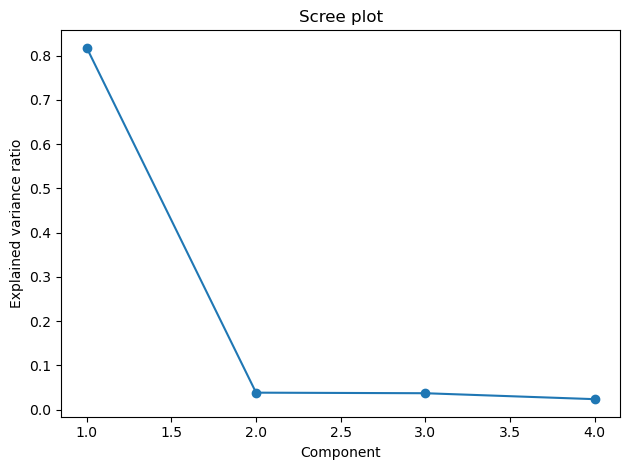

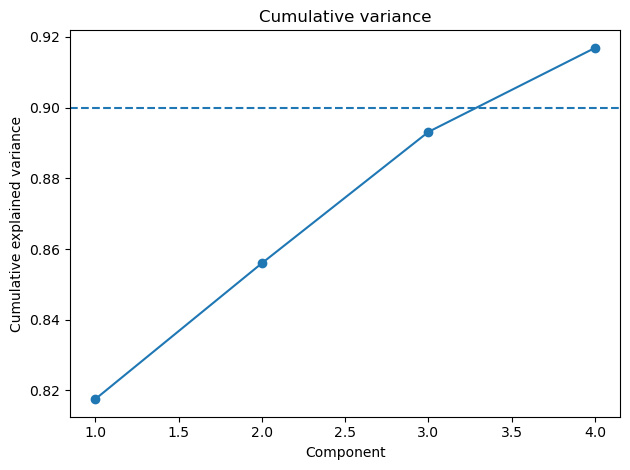

In [7]:

plt.figure()
plt.plot(np.arange(1, len(explained)+1), explained, marker="o")
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(np.arange(1, len(cum)+1), cum, marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Component")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative variance")
plt.tight_layout()
plt.show()


**Biplot (PC1 vs PC2 with top loadings):**


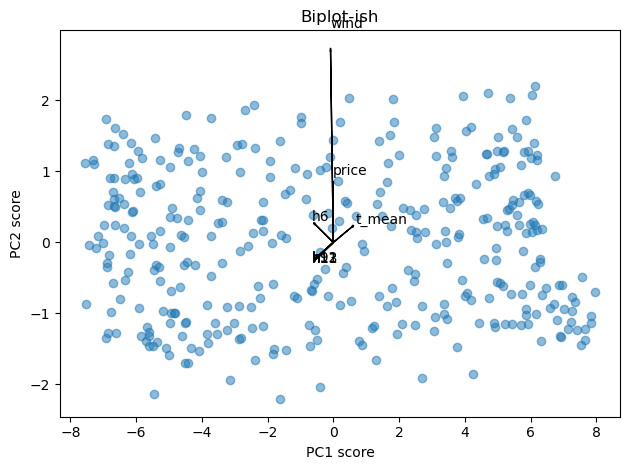

In [8]:

k = 8  # show top-k contributing features
pc1, pc2 = 0, 1
fig, ax = plt.subplots()
ax.scatter(scores.iloc[:, pc1], scores.iloc[:, pc2], alpha=0.5)
ax.set_xlabel("PC1 score"); ax.set_ylabel("PC2 score"); ax.set_title("Biplot-ish")

# arrows for top loadings
L = loadings.iloc[:, [pc1, pc2]]
top = L.abs().sum(1).sort_values(ascending=False).head(k).index
for feat in top:
    x, y = L.loc[feat, :]
    ax.arrow(0, 0, x*3, y*3, head_width=0.03, length_includes_head=True)
    ax.text(x*3*1.1, y*3*1.1, feat)
plt.tight_layout(); plt.show()


---

## 📘 A concrete “story” from the synthetic dataset you generated

* **PC1**: strong positive loadings from h8–h20 → “**daytime demand level**” (base usage + occupancy).
* **PC2**: positive loadings around h6–h10, negative around h18–h22 → “**morning vs evening** balance.”
* **PC3**: negative at h11–h14, positive on `pv` (if included) → “**midday PV shaping net load**.”
  Days with high **PC3** score likely show **big PV influence** (sunny), while low scores indicate cloudy/winter days.




---

## 🔧 Energy use cases

1. **Shape features for forecasting** 🔮

   * Use the first few **scores** (`PC1..PCk`) as compact predictors instead of 24 hourly lags—often reduces collinearity and overfitting.

2. **Portfolio archetypes** 🏢🏬

   * Run PCA on normalized daily profiles of many buildings.
   * Cluster the **scores** to find archetypes (office-like, retail-like, 24/7).

3. **PV + load disentangling** ☀️⚡

   * Include PV generation and irradiance.
   * A PC with strong positive midday kWh and negative PV could indicate midday **self-consumption** dynamics.

4. **Tariff sensitivity** 💶

   * Add price features; PCs showing price-aligned load shifts suggest **price responsiveness**.

5. **Anomaly detection** 🚨

   * Reconstruct using first *k* PCs; large residuals `X - X_recon` flag odd days (stuck HVAC, holidays, sensor faults).


In [12]:
# Reconstruction with first k components
k = 3
W = pca.components_[:k, :]        # [k, d]
S = X_pca[:, :k]                  # [n, k]
Xhat_std = S @ W                  # back in standardized space
Xhat = (Xhat_std * pipe.named_steps["scaler"].scale_) + pipe.named_steps["scaler"].mean_
resid = np.abs(X.values - Xhat)
anomaly_score = resid.mean(1)     # simple score; threshold via quantile


---

## 🧭 Interpreting loadings (rules of thumb)

* **Same sign** loadings → features move together (e.g., h9–h17 all positive → daytime mode).
* **Opposite signs** → trade-off (e.g., morning vs evening peaks).
* Big absolute values → strong contributors.

---

## ⚠️ Pitfalls (and fixes)

* **Unscaled inputs** → PCs dominated by high-variance units → **always standardize**.
* **Mixed regimes** (weekday/weekend, seasons) → run PCA per regime or include dummies first.
* **Too many missing values** → impute sensibly (median/seasonal median) before PCA.
* **Over-interpretation** → PCs are linear combos, not causal truths; validate with domain knowledge.

---

## 📦 Variants you may like

* **IncrementalPCA** for many days/buildings (memory-friendly).
* **KernelPCA** for non-linear shapes (be cautious: interpretability drops).
* **Robust PCA** (decomposition into low-rank + sparse) for outlier-heavy datasets.


---

## ✅ One-page checklist

* [ ] Inputs cleaned, imputed, **standardized**
* [ ] PCs chosen by **elbow** or **≥90%** variance
* [ ] Loadings read and **translated to energy terms**
* [ ] Scores visualized across **season/weekday**
* [ ] Residuals monitored for **anomalies**
* [ ] Scores integrated into **forecasting** or **clustering**
